# Project 3: Semantic Segmentation

#### Maximum Points: 100

This project evaluates your understanding and implementation of a semantic segmentation pipeline. The overall project is divided into several sections, with specific marks assigned to each.


**Mark Distribution**:

<div align = "center">
    <table>
        <tr><td><h3>No.</h3></td> <td><h3>Section</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1.1.</h3></td> <td><h3> Dataset Class</h3></td> <td><h3>15</h3></td> </tr>
        <tr><td><h3>1.2</h3></td> <td><h3> Visualize dataset</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2.</h3></td> <td><h3>  Define Evaluation Metrics</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>3.</h3></td> <td><h3>  Model Definition</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>4.</h3></td> <td><h3>  Train</h3></td> <td><h3>15</h3></td> </tr>
        <tr><td><h3>5.</h3></td> <td><h3>  Inference</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>6.</h3></td> <td><h3> mIoU Score</h3></td> <td><h3>30</h3></td> </tr>
    </table>
        
</div>

---

Breakdown of mIoU Score on Test Dataset **(30 Points)**:

The mIoU Score section evaluates the quality of your segmentation model. Points are awarded based on the achieved mIoU (Mean Intersection over Union) score on the test dataset, as shown below:

<div align="center">
    <table>
        <tr><td><h3>No.</h3></td> <td><h3>mIoU Score Range</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1.</h3></td> <td><h3>>=65% and < 70%</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2.</h3></td> <td><h3>>= 70% and < 73%</h3></td> <td><h3>20</h3></td> </tr>
        <tr><td><h3>3.</h3></td> <td><h3>>= 73%</h3></td><td><h3>30</h3></td> </tr>
    </table>
</div>


---
<h2 style = "color: green;">Dataset Description </h2>

For this Semantic Segmentation Project, you will be working on the **[ICPR Retinal Blood Vessels Dataset](https://www.dropbox.com/scl/fi/tscgh3pxwzfvesnu6l6uv/icpr_prepared.zip?rlkey=8oay8sod3jc1hvwhgqvylaefr&st=udj92wmp&dl=1).**


The dataset consists of **268** train images and **112** test images in 2 classes (**veins** and **background**).

There is no separate validation dataset, you can use the given test dataset for validation.

The dataset is structured as follows:

```
icpr_prepared/
├── train_images/
│   ├── image_100.tif
│   ├── image_101.tif
│   └── ...
├── train_labels/
│   ├── image_100.tif
│   ├── image_101.tif
│   └── ...
├── test_images/
│   ├── image_121.tif
│   ├── image_122.tif
│   └── ...
└── test_labels/
    ├── image_121.tif
    ├── image_122.tif
    └── ...

```
---
Images and their corresponding binary masks are of `.tif` file format and are named with a unique `ImageId` as the filename.

Few samples are shown below:

<img src="https://www.dropbox.com/scl/fi/h0z30ptb8o6cyppfs8h4w/segformer_data_viz_grid_2.png?rlkey=tssqlts8o4kea3kf1um3tijjs&st=0sxunbha&dl=1" width="800" height="800">


**The notebook is divided into multiple grading sections. You have to write code, as mentioned for each section.  For other helper functions, you can write `.py` files and import them in the notebook. You have to submit the notebook along with `.py` files. Your submitted code must be runnable without any bug.**

<h2 style = "color: green;">1. Data Exploration </h2>

In this section, you have to write your custom dataset class and visualize a few images (minimum five images) along with their mask overlayed.

<h2 style = "color: green;">1.1. Dataset Class [15 Points]</h2>

**In this sub-section, write your custom dataset class.**

**For example:**

```python
class SemSegDataset(Dataset):
    """ Generic Dataset class for semantic segmentation datasets.

        Arguments:
            train_image: path to input train images
            train_mask: path to input train mask labels
            train_tfms: transformations (if any)
            label_colors_list: mapping of label value to color code
            classes_to_train: number of classes

            Names of images in the images_folder and masks_folder should be the same for the same samples.
    """
```

In [ ]:
import os
import zipfile
import requests

In [ ]:
def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Done")
    except:
        print("Invalid file")

In [ ]:
URL = r"https://www.dropbox.com/scl/fi/tscgh3pxwzfvesnu6l6uv/icpr_prepared.zip?rlkey=8oay8sod3jc1hvwhgqvylaefr&st=udj92wmp&dl=1"

dataset_name = "retinal_blood_vessel_icpr_seg"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
   download_and_unzip(URL, dataset_zip_path)

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.dataset import ICRDataset
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [89]:
dataset_builder = ICRDataset(
    image_dir="../data/test_images",
    mask_dir="../data/test_labels",
    channel=4,
    img_size=512,
    apply_repeat=False,
    apply_clahe=False,
    batch_size=6
)

dataset = dataset_builder.get_dataset()
test_loader = dataset_builder.get_dataloader(transforms_random=None)

Loading dataset: 100%|███████████████████████████████████████████████████████████████| 112/112 [00:04<00:00, 23.02it/s]


<h2 style = "color: green;">1.2. Visualize dataset [10 Points]</h2>


**In this sub-section,  you have to plot a few images and its mask.**

**For example:**

---

<img src="https://www.dropbox.com/scl/fi/hrkxc7vlziawumy7pwfbt/grid_22.png?rlkey=d9jrybjc993qtbzngekj1sseu&st=7rsy2rik&dl=1">

---

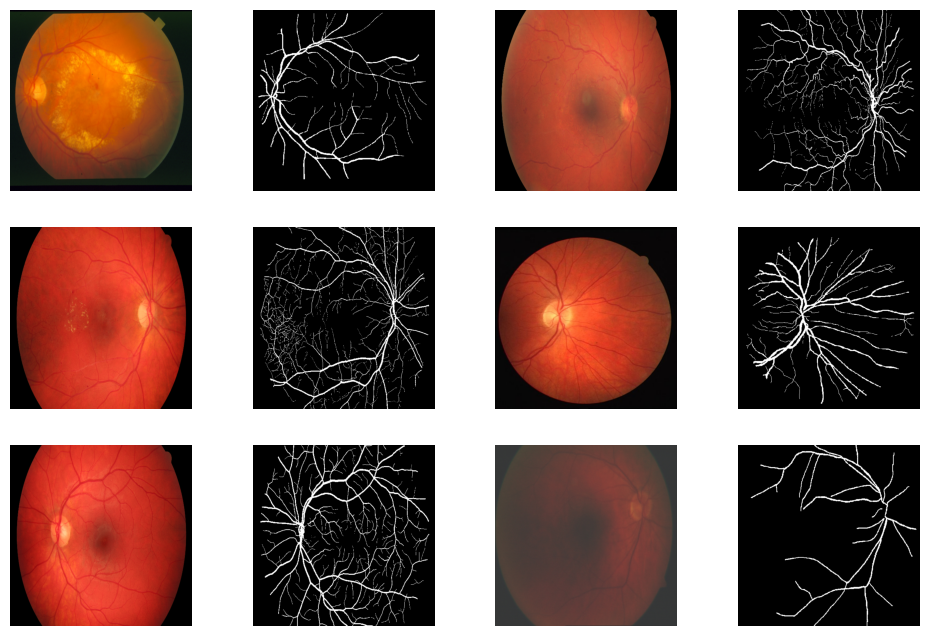

In [95]:
fig, ax = plt.subplots(nrows=3, ncols= 4, figsize=(12, 8))
j, k = 0, 0
idxs = np.random.permutation(100)
for i in range(0, 6):
    idx = np.random.randint(100)
    image = dataset[idx]['image'].permute(1,2,0)
    mask_true = dataset[idx]['label'].squeeze(dim=0)
    ax[j, k].imshow(image.astype(np.uint8))
    ax[j, k].axis('off')
    ax[j, k+1].imshow(mask_true, cmap ='gray')
    ax[j, k+1].axis('off')
    k += 2
    if k>=4: 
        j += 1
        k =0 
    
plt.axis('off')
plt.show()

<h2 style = "color: green;">2. Define Evaluation Metrics [10 Points]</h2>


This project is evaluated on the mean <a href='https://learnopencv.com/intersection-over-union-iou-in-object-detection-and-segmentation/'>IoU</a>.

Mean Intersection over Union (mIoU) is a metric that measures the average overlap between predicted and actual objects in an image or set of images. It's calculated by averaging the Intersection over Union (IoU) of each class in an image.

The following illustration helps in better understanding the IoU:

<img src = "https://www.dropbox.com/scl/fi/e67ri02rqou5oeazdh3rb/intersection-over-union-iou.jpg?rlkey=x5fi1ke6svoas4rh7mfxn3ro7&st=peahed63&dl=1" >

**In this section, you have to implement the mIoU evaluation metric.**

In [107]:
from monai.metrics import MeanIoU

miou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

In [109]:
def compute_metrics(eval_pred):
    # Convert numpy arrays to tensors
    logits = torch.tensor(eval_pred.predictions)
    labels = torch.tensor(eval_pred.label_ids)

    # Convert logits -> binary predictions
    preds = torch.sigmoid(logits)
    preds = (preds > 0.5).float()
    labels = labels.float()

    # Resize labels to match predictions
    if labels.shape[2:] != preds.shape[2:]:
        labels = F.interpolate(labels, size=preds.shape[2:], mode="nearest")

    # Compute mIoU
    miou = miou_metric(preds, labels)
    miou_metric.reset()

    # Reduce to a single scalar
    miou_value = miou.mean().item() 

    return {"mIoU": miou_value}


<h2 style = "color: green;">3. Model [10 Points]</h2>

**In this section, you have to define your model.**

In [103]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import torch

In [105]:
def load_segformer(model_name, num_labels = 1):
    # Load pre-trained SegFormer
    model = SegformerForSemanticSegmentation.from_pretrained(
        model_name, 
        num_labels=num_labels, 
        ignore_mismatched_sizes=True  # <-- this allows loading while changing num_labels
    )
    processor = SegformerImageProcessor.from_pretrained(model_name)

    processor.do_resize = False
    processor.do_rescale = False
    processor.do_normalize = True

    return model, processor

<h2 style = "color: green;">4. Train & Inference</h2>

- **In this section, you have to train the model and infer on sample data.**


- **You can write your trainer class in this section.**


- **If you are using any loss function other than PyTorch standard loss function, you have to define in this section.**


- **This section should also have optimizer and LR-schedular (if using) details.**

<h2 style = "color: green;">4.1. Train [15 Points]</h2>


**Write your training code in this section.**


**This section must contain training plots (use matplotlib or share tensorboard scalars logs).**

**You must have to plot the following:**
- **train loss and validation loss**


- **train accuracy and validation accuracy**


- **Mean Intersection over Union (mIoU) of these classes on validation data.**

**An example of training plots is shown below:**

---

<img src='https://www.dropbox.com/scl/fi/c09gejfn8ivhapp2ngott/loss.png?rlkey=6pennpz1959plb84jlfjytw4p&st=e6ppi338&dl=1'>

---

<img src='https://www.dropbox.com/scl/fi/9h83bbzkifn2kon0gu3wi/accuracy.png?rlkey=v0q17rmi1djljny7ykr0ydk7b&st=zxze36ro&dl=1'>

---

<img src='https://www.dropbox.com/scl/fi/0pq7ivltoeyp1mlkv85oh/miou.png?rlkey=g4iuqvbwih9ld6efvayz5lgjj&st=5bpihwaz&dl=1'>



In [111]:
# See Kaglle Notebook
from transformers import TrainingArguments, TrainerCallback
from src.train import train_segformer
from monai.losses import DiceFocalLoss
import yaml

from monai.transforms import (
    Compose, RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord
)

In [117]:
def compute_loss(model, inputs, return_outputs=False, **kwargs):
    loss_fc = DiceFocalLoss(sigmoid=True)
    labels = inputs.pop("labels").float()
    outputs = model(**inputs)
    logits = outputs.logits

    # resize labels to match logits --> out of (128*128)
    if labels.shape[2:] != logits.shape[2:]:
        labels = F.interpolate(labels, size=logits.shape[2:], mode="nearest")

    loss = loss_fc(logits, labels)
    return (loss, outputs) if return_outputs else loss

class LrLoggerCallback(TrainerCallback):
    def on_epoch_begin(self, args, state, control, **kwargs):
        optimizer = kwargs['optimizer']
        lrs = [group['lr'] for group in optimizer.param_groups]
        print(f"Epoch {int(state.epoch)} - Learning rates: {lrs}")

In [119]:
# Charger la configuration YAML
with open("config.yaml", "r") as f:
    config_dataset = yaml.safe_load(f)

transforms_random = Compose([
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["image", "label"], prob=0.5),
    RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),
    ToTensord(keys=["image", "label"]),
])

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=1e-4,
    remove_unused_columns=False, # IMPORTANT for segmentation
    fp16=False,   # ← IMPORTANT for CPU
    use_cpu=True,

    # Save best model
    load_best_model_at_end=True,  
    save_total_limit=1,
    metric_for_best_model="mIoU"           
)

trainer, model, hf_dataset_train = train_segformer(
    config_dataset=config_dataset,
    training_args=training_args,
    transforms=None,
    callbacks = [LrLoggerCallback()]
)

trainer.compute_loss = compute_loss

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b1-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'


Total params: 13,677,505
Trainable params: 12,032,193
Fraction trainable: 87.97%


Loading dataset: 100%|███████████████████████████████████████████████████████████████| 112/112 [00:23<00:00,  4.72it/s]


<h2 style = "color: green;">5. Inference [10 Points]</h2>

**Plot a few samples with the test image, predicted mask and the predicted mask overlayed onto the retinal eye image.**

**For example:**

---

<img src='https://www.dropbox.com/scl/fi/re6sw5od5k59u4bwgbfgy/prediction_overlay_segformer.png?rlkey=a34frfceiq2pawoovm4zx7b5r&st=qi3fivau&dl=1'>

---



In [137]:
def infrerence(model, image_batch, threshold = 0.2):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():
        outputs = model(pixel_values=image_batch)
        logits = outputs.logits  # Forme: [1, num_labels, H/4, W/4]

    print("Running on:", device)

    # 3. Redimensionnement à la taille originale
    # SegFormer produit des sorties au 1/4 de la résolution
    upsampled_logits = F.interpolate(
        logits,
        size=(512, 512), # (height, width)
        mode='bilinear',
        align_corners=False
    )

    # 4. Obtenir les classes par pixel
    pred_seg = upsampled_logits.squeeze()
    proba = torch.sigmoid(pred_seg)  
    mask = (proba > threshold).float().cpu().numpy()

    return mask

In [123]:
dataset_builder = ICRDataset(
    image_dir="../data/test_images",
    mask_dir="../data/test_labels",
    channel=0,
    img_size=512,
    apply_repeat=True,
    apply_clahe=True,
    batch_size=6
)

dataset = dataset_builder.get_dataset()
test_loader = dataset_builder.get_dataloader(transforms_random=None)

Loading dataset: 100%|███████████████████████████████████████████████████████████████| 112/112 [00:18<00:00,  6.14it/s]


In [163]:
model_path = "../models/results/checkpoint-1020"
model = SegformerForSemanticSegmentation.from_pretrained(model_path)
model.eval()
print("Model correctly load")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model correctly load


In [165]:
image = dataset[12]['image']
mask_true = 
image_batch = image[None]


Running on: cpu


Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu


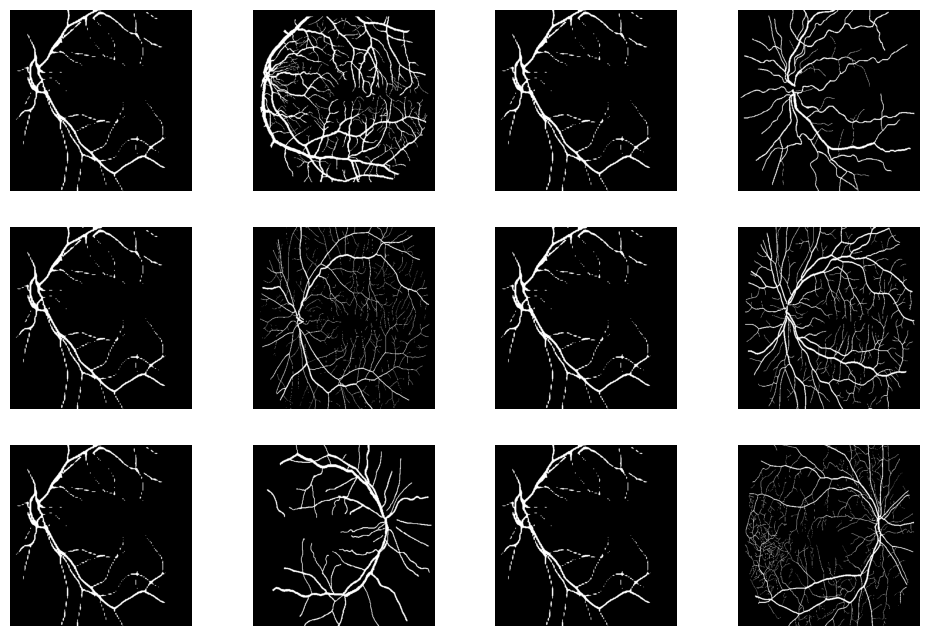

In [173]:
fig, ax = plt.subplots(nrows=3, ncols= 4, figsize=(12, 8))
j, k = 0, 0
for i in range(0, 6):
    idx = np.random.randint(100)
    image = dataset[idx]['image'].permute(1,2,0)
    mask_true = dataset[idx]['label'].squeeze(dim=0)
    mask = infrerence(model, image_batch, threshold = 0.4)
    
    ax[j, k].imshow(mask*255,  cmap ='gray')
    ax[j, k].axis('off')
    ax[j, k+1].imshow(mask_true, cmap ='gray')
    ax[j, k+1].axis('off')
    k += 2
    if k>=4: 
        j += 1
        k =0 
    
plt.axis('off')
plt.show()

Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu
Running on: cpu


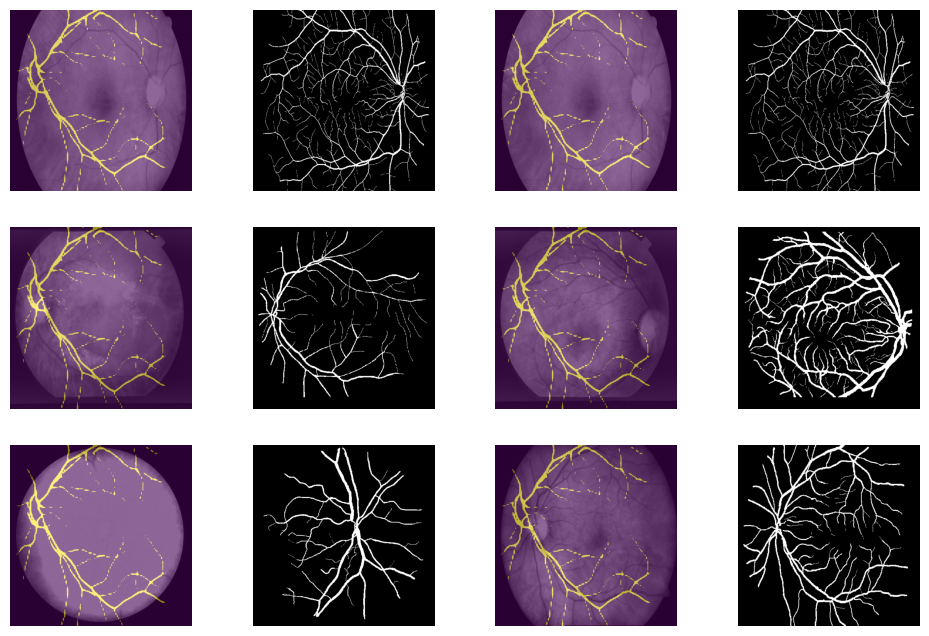

In [177]:
fig, ax = plt.subplots(nrows=3, ncols= 4, figsize=(12, 8))
j, k = 0, 0
for i in range(0, 6):
    idx = np.random.randint(100)
    image = dataset[idx]['image'].permute(1,2,0)
    mask_true = dataset[idx]['label'].squeeze(dim=0)
    mask = infrerence(model, image_batch, threshold = 0.4)
    
    ax[j, k].imshow(image)
    ax[j, k].imshow(mask*255, alpha = 0.6)
    ax[j, k].axis('off')
    ax[j, k+1].imshow(mask_true, cmap ='gray')
    ax[j, k+1].axis('off')
    k += 2
    if k>=4: 
        j += 1
        k =0 
    
plt.axis('off')
plt.show()